<a href="https://colab.research.google.com/github/Mukul1Panwar/Data_visualisation/blob/main/car_sales_ana_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle

In [2]:
!kaggle datasets download -d sachinsachin/car-sales

Dataset URL: https://www.kaggle.com/datasets/sachinsachin/car-sales
License(s): CC0-1.0
  0% 0.00/3.79M [00:00<?, ?B/s]
100% 3.79M/3.79M [00:00<00:00, 731MB/s]


In [3]:
!unzip /content/car-sales.zip

Archive:  /content/car-sales.zip
  inflating: Car Sales.xlsx          


In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_excel("/content/Car Sales.xlsx")

In [6]:
df.shape

(34732, 20)

In [7]:
df.head()

,Date,Customer Name,Dealer_Name,Company,Model,Year,Body Style,Engine,Transmission,Color,Price in thousands,Dealer_Add,Customer Address,CouncilArea,Phone,Gender,Annual Income,Dealer_Location,Dealer_No,Dealer_Region
0,2016-03-09 00:00:00,Geraldine,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,2015,SUV,DoubleÂ Overhead Camshaft,Auto,Black,26,44 Walnut St,68 Studley St,Yarra City Council,8264678,Male,13500,44 Walnut St,06457-3834,Middletown
1,2016-03-12 00:00:00,Gia,C & M Motors Inc,Dodge,Durango,2015,SUV,DoubleÂ Overhead Camshaft,Auto,Black,19,4333 Ogden Ave,85 Turner St,Yarra City Council,6848189,Male,1480000,4333 Ogden Ave,60504-7114,Aurora
2,2016-04-02 00:00:00,Gianna,Capitol KIA,Cadillac,Eldorado,2015,Passenger,Overhead Camshaft,Manual,Red,31,3 Green Tree Trl,25 Bloomburg St,Yarra City Council,7298798,Male,1035000,3 Green Tree Trl,38701-8047,Greenville
3,2016-04-02 00:00:00,Giselle,Chrysler of Tri-Cities,Toyota,Celica,2016,SUV,Overhead Camshaft,Manual,Pale White,14,3203 W Marie St,18/659 Victoria St,Yarra City Council,6257557,Male,13500,3203 W Marie St,99301-3882,Pasco
4,2017-04-03 00:00:00,Grace,Chrysler Plymouth,Acura,TL,2015,Hatchback,DoubleÂ Overhead Camshaft,Auto,Red,24,6137 S Us-51,5 Charles St,Yarra City Council,7081483,Male,1465000,6137 S Us-51,53546-9427,Janesville


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34732 entries, 0 to 34731
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Date                34732 non-null  object
 1   Customer Name       34730 non-null  object
 2   Dealer_Name         34732 non-null  object
 3   Company             34732 non-null  object
 4   Model               34732 non-null  object
 5   Year                34732 non-null  int64 
 6   Body Style          34732 non-null  object
 7   Engine              34732 non-null  object
 8   Transmission        34732 non-null  object
 9   Color               34732 non-null  object
 10  Price in thousands  34732 non-null  int64 
 11  Dealer_Add          34732 non-null  object
 12  Customer Address    34732 non-null  object
 13  CouncilArea         34729 non-null  object
 14  Phone               34732 non-null  int64 
 15  Gender              34732 non-null  object
 16  Annual Income       34

In [9]:
df.isna().sum().sum()

np.int64(5)

In [10]:
df = df.drop(columns=['Customer Name', 'Dealer_Name', 'Dealer_Add', 'Customer Address', 'Phone', 'Gender', 'Annual Income', 'Dealer_Location','Dealer_No '], axis=1)

In [11]:
df['CouncilArea'] = df['CouncilArea'].fillna(df['CouncilArea'].mode()[0])

In [12]:
df.isna().sum().sum()

np.int64(0)

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
df['Month'] = df['Date'].dt.month

In [15]:
from matplotlib import pyplot as plt
import seaborn as sns

# Outliers

In [16]:
q1 = df['Price in thousands'].quantile(0.25)
q3 = df['Price in thousands'].quantile(0.75)

iqr = q3=q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers = df[(df['Price in thousands'] < lower_fence) | (df['Price in thousands']> upper_fence)]

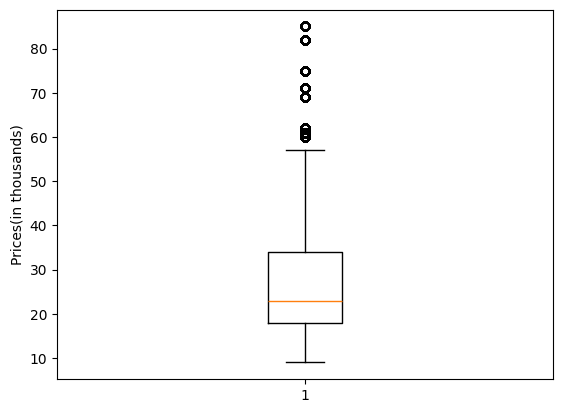

In [25]:
plt.boxplot(df['Price in thousands'])
plt.ylabel("Prices(in thousands)")
plt.show()

In [ ]:
df.shape

(34732, 12)

In [ ]:
df.head(5)

,Date,Company,Model,Year,Body Style,Engine,Transmission,Color,Price in thousands,CouncilArea,Dealer_Region,Month
0,2016-03-09,Ford,Expedition,2015,SUV,DoubleÂ Overhead Camshaft,Auto,Black,26,Yarra City Council,Middletown,3
1,2016-03-12,Dodge,Durango,2015,SUV,DoubleÂ Overhead Camshaft,Auto,Black,19,Yarra City Council,Aurora,3
2,2016-04-02,Cadillac,Eldorado,2015,Passenger,Overhead Camshaft,Manual,Red,31,Yarra City Council,Greenville,4
3,2016-04-02,Toyota,Celica,2016,SUV,Overhead Camshaft,Manual,Pale White,14,Yarra City Council,Pasco,4
4,2017-04-03,Acura,TL,2015,Hatchback,DoubleÂ Overhead Camshaft,Auto,Red,24,Yarra City Council,Janesville,4


# Count the Number of Cars based on range of prices

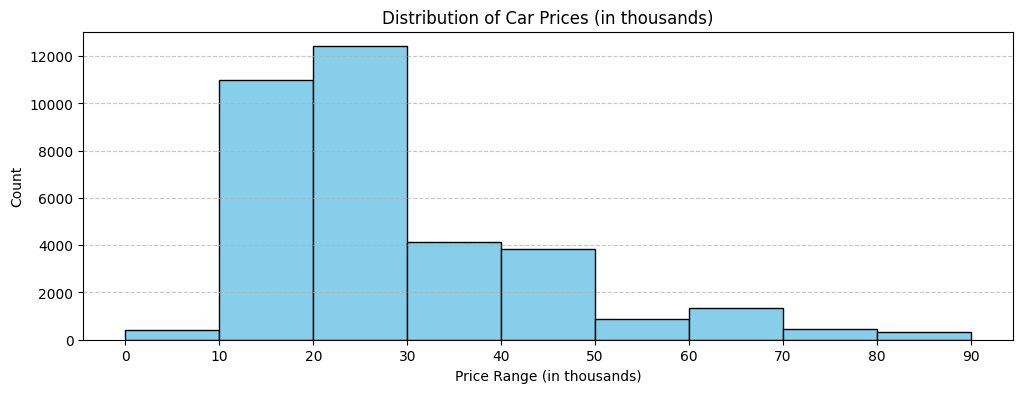

In [ ]:
plt.figure(figsize=(12,4))
custom_bins = np.arange(0, df['Price in thousands'].max() + 10, 10)
plt.hist(x=df['Price in thousands'], bins=custom_bins, color='skyblue', edgecolor='black')
plt.title('Distribution of Car Prices (in thousands)')
plt.xlabel("Price Range (in thousands)")
plt.ylabel("Count")
plt.xticks(custom_bins)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
df.groupby('Company')['Dealer_Region'].apply(lambda x: x.mode()[0]) # calculating the most frequent 'Dealer_Region' for each car 'Company'


,Dealer_Region
Company,
Acura,Janesville
Audi,Austin
BMW,Janesville
Buick,Austin
Cadillac,Scottsdale
Chevrolet,Scottsdale
Chrysler,Janesville
Dodge,Janesville
Ford,Janesville


# The Average price of each car company

---



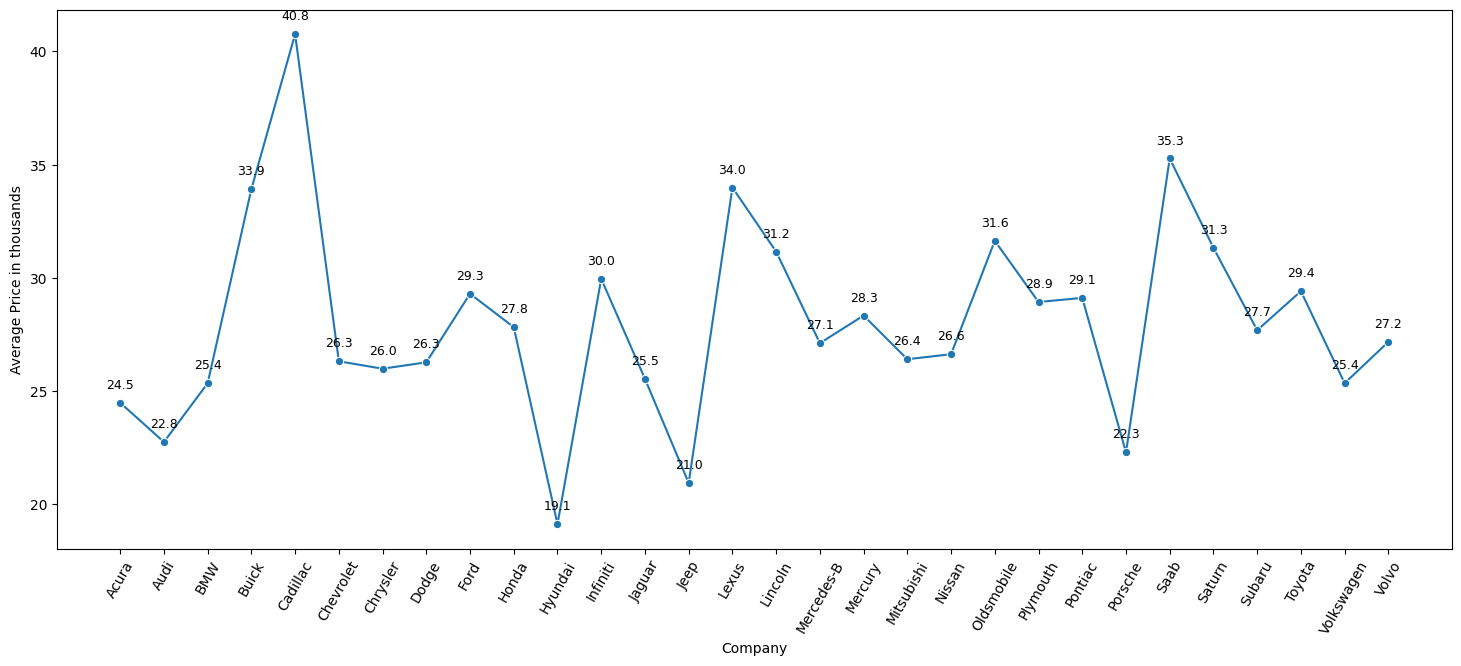

In [ ]:
plt.figure(figsize=(18,7))

company_avg_prices = df.groupby('Company')['Price in thousands'].mean()

sns.lineplot(x=company_avg_prices.index,y=company_avg_prices.values,marker='o')
plt.ylabel("Average Price in thousands")
plt.xticks(rotation=60)

for i, price in enumerate(company_avg_prices.values):
    plt.text(i, price + 0.5, f'{price:.1f}', ha='center', va='bottom', fontsize=9)

plt.show()

# Body Style Distribution in 2015 (Pie Chart)

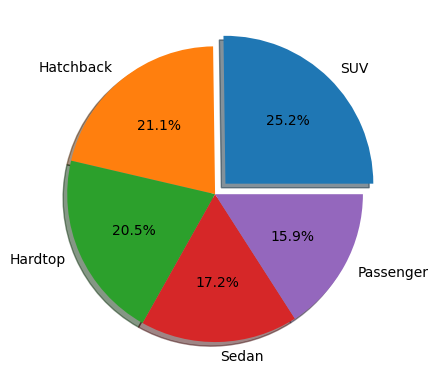

In [ ]:
df6 = df[df['Year']==2015]['Body Style'].value_counts()
explods = [0.1 if i==0 else 0 for i in range(len(df6))]
plt.pie(df6.values,labels=df6.index,autopct='%1.1f%%',shadow=True,explode=explods)
plt.show()

# Body Style Distribution (Pie Chart)

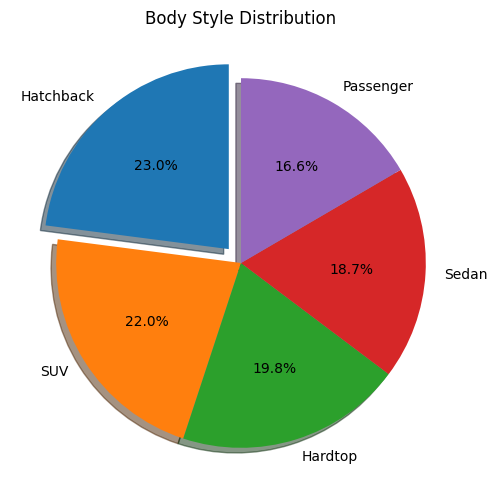

In [ ]:
plt.figure(figsize=(6,6))


df5 = df['Body Style'].value_counts()

explode = [0.1 if i==0 else 0 for i in range(len(df5))]

plt.pie(df5.values,labels=df5.index,autopct='%1.1f%%',explode=explode,shadow=True,startangle=90)
plt.title("Body Style Distribution")
plt.show()


# Count the Sales by Dealer Region

/tmp/ipython-input-2699887598.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df4.index, y=df4.values,palette='viridis')


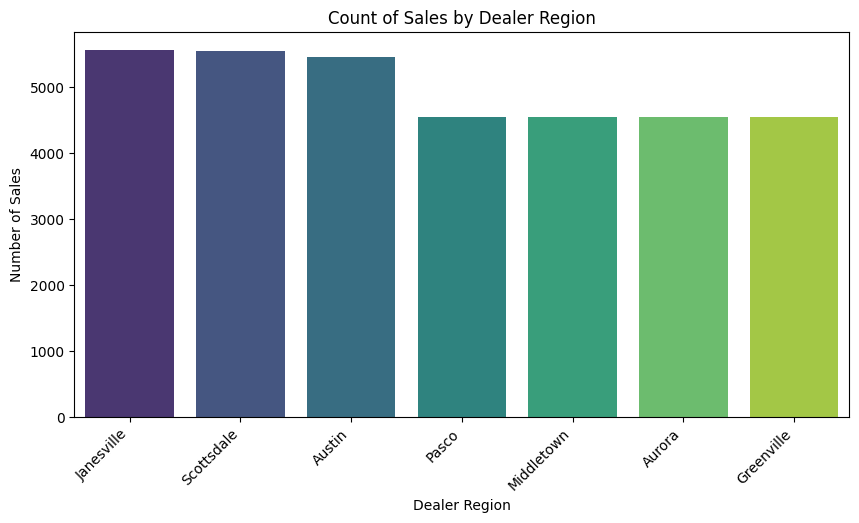

In [ ]:
plt.figure(figsize=(10, 5))
df4 = df['Dealer_Region'].value_counts()
sns.barplot(x=df4.index, y=df4.values,palette='viridis')
plt.title('Count of Sales by Dealer Region')
plt.xlabel('Dealer Region')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45, ha='right')
plt.show()

# Number of different Body Styles of Cars

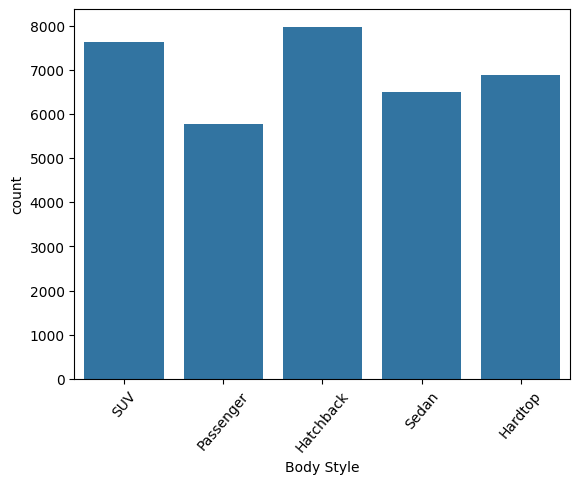

In [ ]:
sns.countplot(data=df,x='Body Style')
plt.xticks(rotation=50)
plt.show()

# Sales Performance Analysis Over a Month(2016)

<Axes: xlabel='Month', ylabel='count'>

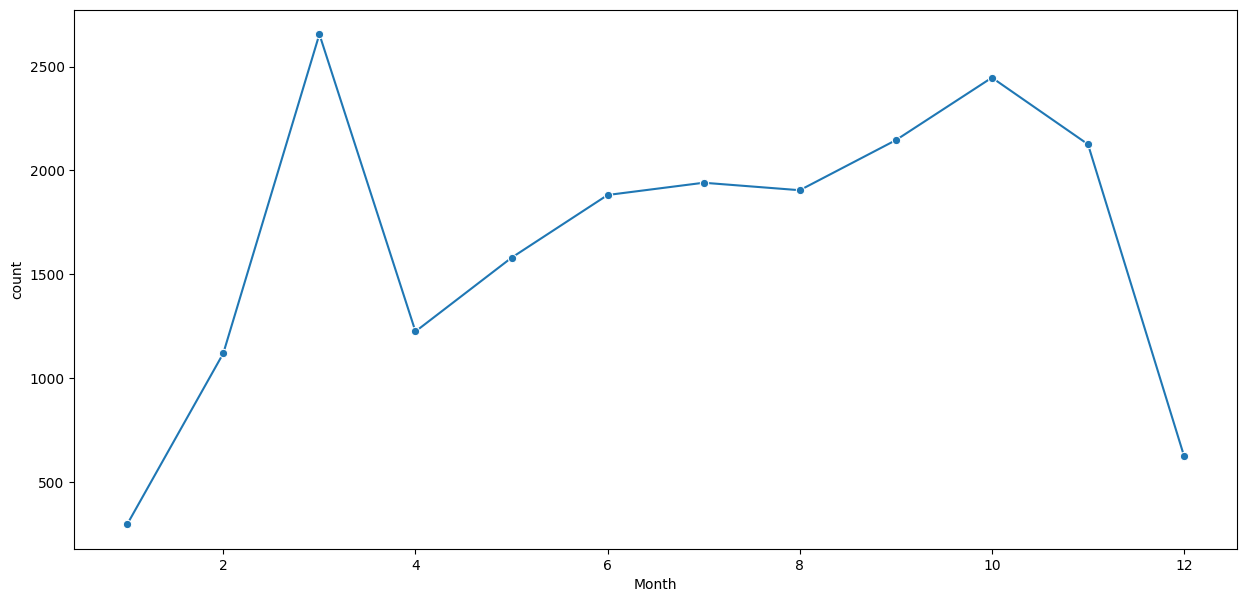

In [ ]:
plt.figure(figsize=(15,7))
sns.lineplot(
    data=df[df['Year']==2016].groupby('Month').size().reset_index(name='count'),
    x='Month',
    y='count',
    marker='o'
)


# Number of Car sells in 2015

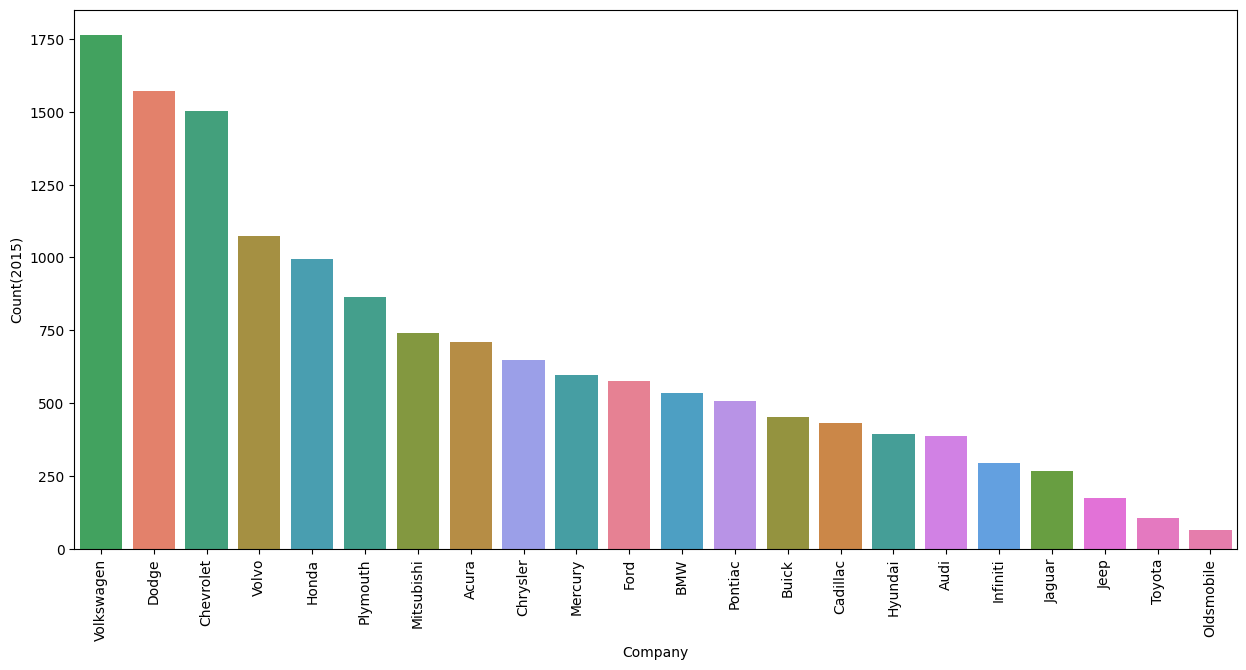

In [ ]:
plt.figure(figsize=(15,7))
df2 = df[df['Year']==2015]
sns.countplot(data=df2,x='Company',order=df2['Company'].value_counts().index,hue='Company')
plt.xlabel("Company")
plt.ylabel("Count(2015)")
plt.xticks(rotation=90)
plt.show()

# Number of Car sells

/tmp/ipython-input-2271965854.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Company',order=df['Company'].value_counts().index, palette='plasma')


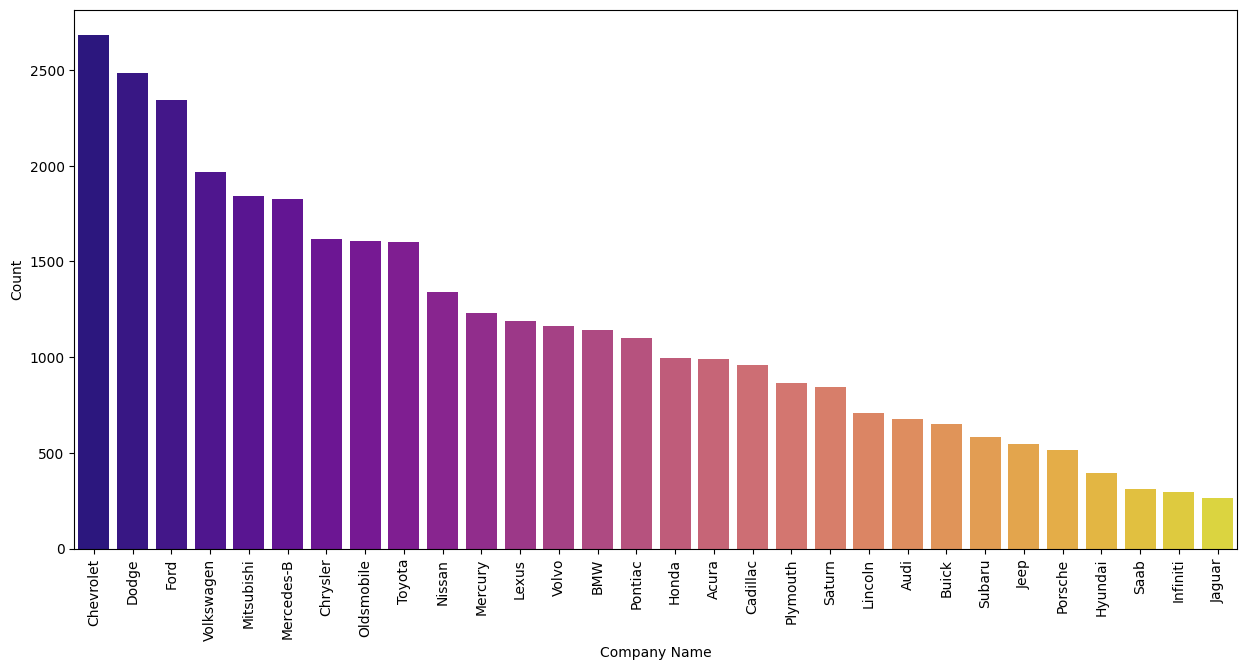

In [ ]:
plt.figure(figsize=(15,7))
sns.countplot(data=df,x='Company',order=df['Company'].value_counts().index, palette='plasma')
plt.xlabel('Company Name')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()